# LucidFence Fleet Intelligence

Análisis descriptivo y reproducible sobre datos locales. No realiza predicciones, no usa servicios externos y no accede a credenciales.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from core.product import build_analytics

ROOT = Path.cwd()
history = [json.loads(line) for line in (ROOT/'data/stats_history.jsonl').read_text().splitlines() if line.strip()]
trails = [json.loads(line) for line in (ROOT/'data/trails.jsonl').read_text().splitlines() if line.strip()]
print(f'{len(history)} ciclos históricos · {len(trails)} puntos GPS')

369 ciclos históricos · 832 puntos GPS


In [2]:
analytics = build_analytics([], [], [], history, trails=trails)
intel = analytics['fleet_intelligence']
pd.Series({
    'Calidad de datos': intel['signal_quality_score'],
    'Continuidad %': intel['quality_components']['continuity_percent'],
    'Cobertura GPS %': intel['quality_components']['gps_coverage_percent'],
    'Gaps': intel['gap_count'],
    'Transiciones': intel['geofence_transitions'],
    'Delta conformidad (pp)': intel['compliance_delta_points'],
}, name='valor').to_frame()

,valor
Calidad de datos,95
Continuidad %,85
Cobertura GPS %,100
Gaps,55
Transiciones,16
Delta conformidad (pp),33


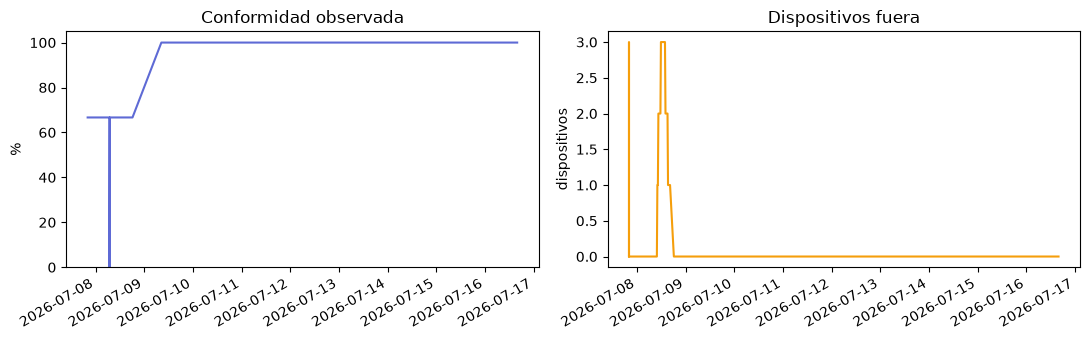

In [3]:
frame = pd.DataFrame(history)
frame['ts'] = pd.to_datetime(frame['ts'], utc=True)
frame['compliance_percent'] = ((frame['devices_total']-frame['non_compliant'])/frame['devices_total'].clip(lower=1)*100)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
frame.plot(x='ts', y='compliance_percent', ax=axes[0], legend=False, color='#5e6ad5', title='Conformidad observada')
axes[0].set_ylim(0, 105); axes[0].set_ylabel('%'); axes[0].set_xlabel('')
frame.plot(x='ts', y='outside', ax=axes[1], legend=False, color='#f59e0b', title='Dispositivos fuera')
axes[1].set_ylabel('dispositivos'); axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

In [4]:
print('Hallazgos accionables:')
for item in intel['recommendations']:
    print('-', item)
print('\nMétodo:', intel['evidence']['method'])
print('Fórmula:', intel['evidence']['quality_formula'])
assert intel['evidence']['prediction'] is False
assert 0 <= intel['signal_quality_score'] <= 100
print('NOTEBOOK_VERIFICATION_PASS')

Hallazgos accionables:
- Investiga 55 interrupciones superiores a 30 minutos.
- Revisa los dispositivos con más transiciones de geovalla.

Método: observed-local-history
Fórmula: 40% recencia + 30% continuidad + 20% cobertura GPS + 10% profundidad histórica
NOTEBOOK_VERIFICATION_PASS
